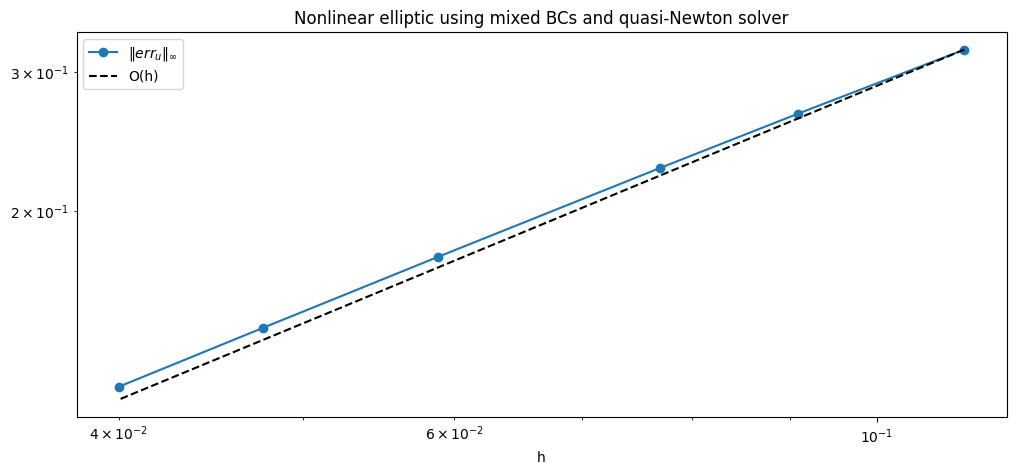

In [5]:
import sympy as sp
x, y = sp.symbols('x y')
from FD import FDlapl_robin_sparse, rhs_robin, dir_mask_val, apply_dir, div_I_grad_u
from scipy.sparse.linalg import spsolve
import numpy as np
from custom_solvers import quasi_newton_solver
import matplotlib.pyplot as plt

u_ex = sp.cos(sp.pi*x) * sp.sin(sp.pi*y)
v_ex = sp.cos(sp.pi*x) * sp.sin(sp.pi*y)
u_ex_fn = sp.lambdify((x, y), u_ex, 'numpy')
v_ex_fn = sp.lambdify((x, y), v_ex, 'numpy')



Du, Dv, chi = 1.0, 1.0, 1.0

f_v = -Dv * (sp.diff(v_ex, x, 2) + sp.diff(v_ex, y, 2))
Jx  = u_ex * sp.diff(v_ex, x)
Jy  = u_ex * sp.diff(v_ex, y)
f_u = -Du * (sp.diff(u_ex, x, 2) + sp.diff(u_ex, y, 2)) \
      + chi * (sp.diff(Jx, x) + sp.diff(Jy, y))

f_u_fn = sp.lambdify((x, y), sp.simplify(f_u), 'numpy')
f_v_fn = sp.lambdify((x, y), sp.simplify(f_v), 'numpy')

#Neumann on L/R, Dirichlet (u=0) on B/T
alpha_u = {'L': 1, 'R': 1, 'B': 0, 'T': 0}
beta_u  = {'L': 0, 'R': 0, 'B': 1, 'T': 1}
g_u   = {'L': 0,   'R': 0, 'B': 0, 'T': 0}
robin_u={'alpha': alpha_u, 'beta': beta_u, 'g': g_u}
alpha_v = {'L': 1, 'R': 1, 'B': 0, 'T': 0}
beta_v  = {'L': 0, 'R': 0, 'B': 1, 'T': 1}
g_v   = {'L': 0,   'R': 0, 'B': 0, 'T': 0}
robin_v={'alpha': alpha_v, 'beta': beta_v, 'g': g_v}


N_list=[8,10,12,16,20,24]
err_u_inf, err_v_inf = [], []
err_u_2,   err_v_2   = [], []
hs = []

for N in N_list:
    M   = N
    hx  = hy = 1.0 / (N + 1)
    xi  = np.linspace(0, 1, N + 2)
    yj  = np.linspace(0, 1, M + 2)
    XX, YY = np.meshgrid(xi, yj, indexing='ij')
    Av   = -Dv * FDlapl_robin_sparse(2, N, hx, alpha_v, beta_v, M, hy)
    rhsv = rhs_robin(2, f_v_fn(XX, YY).reshape(-1), N, hx, alpha_v, g_v, xi, M, hy, yj)
    mask_v, uD_v = dir_mask_val(2, N, alpha_v, beta_v, g_v, xi, M, yj)
    Av, rhsv = apply_dir(Av, rhsv, mask_v, uD_v)

    Au    = -Du * FDlapl_robin_sparse(2, N, hx, alpha_u, beta_u, M, hy)
    rhs_u = rhs_robin(2, f_u_fn(XX, YY).reshape(-1), N, hx, alpha_u, g_u, xi, M, hy, yj)
    mask_u, uD_u = dir_mask_val(2, N, alpha_u, beta_u, g_u, xi, M, yj)
    Au, rhs_u = apply_dir(Au, rhs_u, mask_u, uD_u)

    v_h = spsolve(Av, rhsv)
    
    def F_u(u_vec):
        chemo = chi * div_I_grad_u(u_vec, v_h, M, N, hx, hy, np.ones((N+2)*(M+2), dtype=bool))
        chemo[mask_u] = 0.0
        return Au @ u_vec + chemo - rhs_u
    
    
    u_h, _ = quasi_newton_solver(np.zeros((N+2)*(M+2)), F_u, rel_tol=1e-10, maxiter=500)


    u_ref = u_ex_fn(XX, YY).reshape(-1)
    v_ref = v_ex_fn(XX, YY).reshape(-1)
    err_u_inf.append(np.max(np.abs(u_h[1:-1] - u_ref[1:-1])))
    err_u_2  .append(np.sqrt(hx*hy) * np.linalg.norm(u_h - u_ref))
    err_v_inf.append(np.max(np.abs(v_h - v_ref)))
    err_v_2  .append(np.sqrt(hx*hy) * np.linalg.norm(v_h - v_ref))
    hs.append(hx)

plt.figure(figsize=(12, 5))
plt.loglog(hs, err_u_inf, 'o-', label=r'$\|err_u\|_\infty$')
plt.loglog(hs, (err_u_inf[0]/hs[0])*np.asarray(hs), 'k--', label='O(h)')
plt.title('Nonlinear elliptic using mixed BCs and quasi-Newton solver')
plt.xlabel('h')

plt.legend()
plt.show()



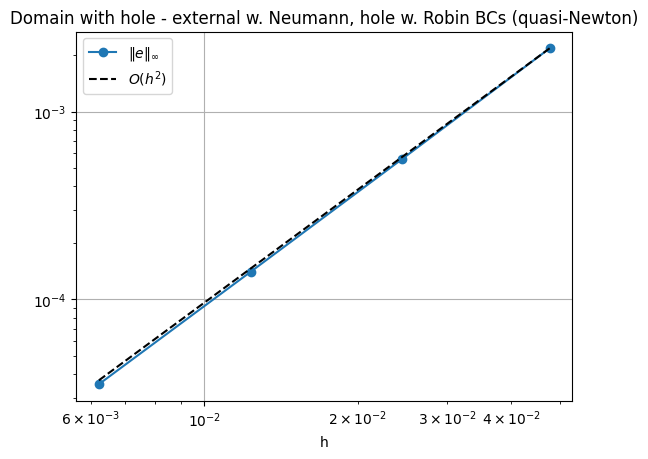

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import spsolve
from FD import FDlapl_robin_sparse, rhs_robin, apply_hole_robin_sparse

pi = np.pi
u_ex  = lambda x, y:  np.cos(pi*x) * np.cos(pi*y)
ux    = lambda x, y: -pi*np.sin(pi*x)*np.cos(pi*y)
uy    = lambda x, y: -pi*np.cos(pi*x)*np.sin(pi*y)
f_fn  = lambda x, y: -2*pi**2 * np.cos(pi*x)*np.cos(pi*y)

al_o = {s: 1 for s in 'LRBT'}
be_o = {s: 0 for s in 'LRBT'}
g_o  = {s: 0 for s in 'LRBT'}

al_h = {s: 1 for s in 'LRBT'}
be_h = {s: 1 for s in 'LRBT'}
g_h  = {
    'L': lambda x, y:  ux(x, y) + u_ex(x, y),
    'R': lambda x, y: -ux(x, y) + u_ex(x, y),
    'B': lambda x, y:  uy(x, y) + u_ex(x, y),
    'T': lambda x, y: -uy(x, y) + u_ex(x, y),
}

HOLE_X = (0.25, 0.45)
HOLE_Y = (0.60, 0.80)

N_list = [20, 40, 80, 160]
errs, hs = [], []

for N in N_list:
    M  = N
    hx = hy = 1.0 / (N + 1)
    xi = np.linspace(0, 1, N + 2)
    yj = np.linspace(0, 1, M + 2)
    XX, YY = np.meshgrid(xi, yj, indexing='ij')

    A   = FDlapl_robin_sparse(2, N, hx, al_o, be_o, M, hy)
    rhs = rhs_robin(2, f_fn(XX, YY).reshape(-1), N, hx, al_o, g_o, xi, M, hy, yj)

    i0 = max(2, np.searchsorted(xi, HOLE_X[0]))
    i1 = min(N-1, np.searchsorted(xi, HOLE_X[1]) - 1)
    j0 = max(2, np.searchsorted(yj, HOLE_Y[0]))
    j1 = min(M-1, np.searchsorted(yj, HOLE_Y[1]) - 1)

    A_h, rhs_h = apply_hole_robin_sparse(
        A, rhs, N, hx, M, hy, i0, i1, j0, j1, al_h, be_h, g_h, xi, yj
    )
    u_sol = spsolve(A_h, rhs_h)

    active = np.ones((N+2, M+2), dtype=bool)
    active[i0:i1+1, j0:j1+1] = False
    active = active.reshape(-1)

    u_ref = u_ex(XX, YY).reshape(-1)
    err = np.max(np.abs(u_sol[active] - u_ref[active]))
    errs.append(err); hs.append(hx)

hs, errs = np.array(hs), np.array(errs)
rates = np.log(errs[:-1]/errs[1:]) / np.log(hs[:-1]/hs[1:])

plt.loglog(hs, errs, 'o-', label=r'$\|e\|_\infty$')
plt.loglog(hs, errs[0]*(hs/hs[0])**2, 'k--', label=r'$O(h^2)$')
plt.xlabel('h'); 
plt.title('Domain with hole - external w. Neumann, hole w. Robin BCs (quasi-Newton)'); plt.legend(); plt.grid(True)
plt.show()
